# Tiền xử lý dữ liệu Luật Đường bộ 35/2024/QH15

Notebook này thực hiện chuyển đổi file JSON sang DataFrame pandas để tiền xử lý dữ liệu văn bản luật.

## 1. Import thư viện

In [1]:
import pandas as pd
import json
import re
from pathlib import Path

from underthesea import word_tokenize, pos_tag, sent_tokenize, ner

ModuleNotFoundError: No module named 'pandas'

## 2. Đọc file JSON

In [ ]:
# Đọc file JSON
with open('luat_duong_bo_35-2024.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# Hiển thị thông tin cơ bản
print(f"Tiêu đề: {data['title']}")
print(f"Số hiệu: {data['law_number']}")
print(f"Năm: {data['year']}")
print(f"Tổng số trang: {data['total_pages']}")
print(f"Số lượng pages: {len(data['pages'])}")
print(f"Độ dài full_text: {len(data['full_text'])} ký tự")

Tiêu đề: LUẬT TRẬT TỰ, AN TOÀN GIAO THÔNG ĐƯỜNG BỘ
Số hiệu: 35/2024/QH15
Năm: 2024
Tổng số trang: 69
Số lượng pages: 69
Độ dài full_text: 149931 ký tự


## 3. Chuyển đổi sang DataFrame

In [ ]:
# Tạo DataFrame từ pages
df_pages = pd.DataFrame(data['pages'])

# Thêm metadata vào mỗi page
df_pages['law_number'] = data['law_number']
df_pages['title'] = data['title']
df_pages['year'] = data['year']

# Thêm các features cơ bản
df_pages['word_count'] = df_pages['content'].str.split().str.len()
df_pages['char_count'] = df_pages['content'].str.len()

print("Shape:", df_pages.shape)
print("\nColumns:", df_pages.columns.tolist())
print("\nPreview:")
df_pages[['page_number', 'word_count', 'char_count', 'law_number']].head(10)

Shape: (69, 7)

Columns: ['page_number', 'content', 'law_number', 'title', 'year', 'word_count', 'char_count']

Preview:


,page_number,word_count,char_count,law_number
0,1,335,1522,35/2024/QH15
1,2,486,2252,35/2024/QH15
2,3,519,2405,35/2024/QH15
3,4,474,2086,35/2024/QH15
4,5,427,1960,35/2024/QH15
5,6,501,2311,35/2024/QH15
6,7,440,2012,35/2024/QH15
7,8,477,2127,35/2024/QH15
8,9,513,2251,35/2024/QH15
9,10,540,2403,35/2024/QH15


## 4. Xem nội dung một page mẫu

In [ ]:
# Xem nội dung page đầu tiên
print(f"Page {df_pages.iloc[0]['page_number']}:")
print(f"Word count: {df_pages.iloc[0]['word_count']}")
print(f"Char count: {df_pages.iloc[0]['char_count']}")
print("\nContent preview (500 ký tự đầu):")
print(df_pages.iloc[0]['content'][:500])

Page 1:
Word count: 335
Char count: 1522

Content preview (500 ký tự đầu):
CÔNG BÁO/Số 983 + 984/Ngày 25-8-2024 3
QUỐC HỘI CỘNG HÒA XÃ HỘI CHỦ NGHĨA VIỆT NAM
Độc lập - Tự do - Hạnh phúc
Luật số: 35/2024/QH15
LUẬT
ĐƯỜNG BỘ
Căn cứ Hiến pháp nước Cộng hòa xã hội chủ nghĩa Việt Nam;
Quốc hội ban hành Luật Đường bộ.
Chương I
NHỮNG QUY ĐỊNH CHUNG
Điều 1. Phạm vi điều chỉnh
Luật này quy định về hoạt động đường bộ và quản lý nhà nước về hoạt động
đường bộ.
Điều 2. Giải thích từ ngữ
Trong Luật này, các từ ngữ dưới đây được hiểu như sau:
1. Hoạt động đường bộ bao gồm: hoạt động 


## 5. Tiền xử lý 

In [ ]:
#Tao copy cua dataframes
df = df_pages.copy()

1. LOWERCASING

In [ ]:
df['content'] = df['content'].apply(lambda x: " ".join(x.lower() for x in x.split()))

print("After lowercase:")
print(df.iloc[0]['content'][:500])

After lowercase:
công báo/số 983 + 984/ngày 25-8-2024 3 quốc hội cộng hòa xã hội chủ nghĩa việt nam độc lập - tự do - hạnh phúc luật số: 35/2024/qh15 luật đường bộ căn cứ hiến pháp nước cộng hòa xã hội chủ nghĩa việt nam; quốc hội ban hành luật đường bộ. chương i những quy định chung điều 1. phạm vi điều chỉnh luật này quy định về hoạt động đường bộ và quản lý nhà nước về hoạt động đường bộ. điều 2. giải thích từ ngữ trong luật này, các từ ngữ dưới đây được hiểu như sau: 1. hoạt động đường bộ bao gồm: hoạt động 


2. REMOVING PUNCTUATION

In [ ]:
df['content'] = df['content'].str.replace('/', ' ', regex=False)
df['content'] = df['content'].str.replace(r'[^\w\s]', '', regex=True)

print("After removing punctuation:")
print(df.iloc[0]['content'][:500])

After removing punctuation:
công báo số 983  984 ngày 2582024 3 quốc hội cộng hòa xã hội chủ nghĩa việt nam độc lập  tự do  hạnh phúc luật số 35 2024 qh15 luật đường bộ căn cứ hiến pháp nước cộng hòa xã hội chủ nghĩa việt nam quốc hội ban hành luật đường bộ chương i những quy định chung điều 1 phạm vi điều chỉnh luật này quy định về hoạt động đường bộ và quản lý nhà nước về hoạt động đường bộ điều 2 giải thích từ ngữ trong luật này các từ ngữ dưới đây được hiểu như sau 1 hoạt động đường bộ bao gồm hoạt động về quy hoạch đầ


3. REMOVING STOP WORDS

3.1. Load Stopwords tu file

In [ ]:
stopwords_file = 'resource/vietnamese-stopwords.txt'  # Hoặc 'stopwords_vi.txt'

try:
    with open(stopwords_file, 'r', encoding='utf-8') as f:
        stopwords_vi = set([line.strip().lower() for line in f if line.strip()])
    
    print(f"✓ Đã load {len(stopwords_vi)} stopwords từ file: {stopwords_file}")
    print(f"\n10 stopwords đầu tiên: {list(stopwords_vi)[:10]}")
    
except FileNotFoundError:
    print(f"Không tìm thấy file: {stopwords_file}")
    print("\nCác file trong thư mục hiện tại:")
    import os
    txt_files = [f for f in os.listdir('.') if f.endswith('.txt')]
    for f in txt_files:
        print(f"  - {f}")

✓ Đã load 1942 stopwords từ file: resource/vietnamese-stopwords.txt

10 stopwords đầu tiên: ['là phải', 'ráo nước', 'cơ mà', 'đúng ra', 'nước ăn', 'dễ như chơi', 'nghe không', 'con con', 'hay tin', 'qua lần']


3.2. Removing stopword

In [ ]:
df['content'] = df['content'].apply(lambda x: " ".join(x for x in x.split() if x not in stopwords_vi))

df['content']

0     công báo 983 984 2582024 3 quốc hội cộng hòa x...
1     4 công báo 983 984 2582024 thông đường bảo đảm...
2     công báo 983 984 2582024 5 kết cấu hạ tầng đườ...
3     6 công báo 983 984 2582024 c giao thông vận tả...
4     công báo 983 984 2582024 7 3 phủ quy định chi ...
                            ...                        
64    công báo 983 984 2582024 67 a thành lập quy đị...
65    68 công báo 983 984 2582024 chương v quản lý h...
66    công báo 983 984 2582024 69 2 tra kiểm tra xử ...
67    70 công báo 983 984 2582024 3 sửa đổi bổ sung ...
68    công báo 983 984 2582024 71 5a đoạn giao chéo ...
Name: content, Length: 69, dtype: str

4. TEXT STANDARDIZATION

4.1. Tao dictionary cac tu viet tat

In [ ]:
# Dictionary đầy đủ các từ viết tắt tiếng Việt
vietnamese_abbreviations = {
    # === CƠ QUAN NHÀ NƯỚC ===
    'qh15': 'quốc hội khóa 15',
    'qh': 'quốc hội',
    'cp': 'chính phủ',
    'ttcp': 'thủ tướng chính phủ',
    'ctqh': 'chủ tịch quốc hội',
    'ubtvqh': 'ủy ban thường vụ quốc hội',
    'ubnd': 'ủy ban nhân dân',
    'hđnd': 'hội đồng nhân dân',
    'tandtc': 'tòa án nhân dân tối cao',
    'vksndtc': 'viện kiểm sát nhân dân tối cao',
    'ktnn': 'kiểm toán nhà nước',
    'ttcp': 'thanh tra chính phủ',
    
    # === BỘ, NGÀNH ===
    'gtvt': 'giao thông vận tải',
    'ca': 'công an',
    'qp': 'quốc phòng',
    'nn&ptnt': 'nông nghiệp và phát triển nông thôn',
    'tn&mt': 'tài nguyên và môi trường',
    'khcn': 'khoa học và công nghệ',
    'tt&tt': 'thông tin và truyền thông',
    'gd&đt': 'giáo dục và đào tạo',
    'yt': 'y tế',
    'lđtb&xh': 'lao động thương binh và xã hội',
    'tc': 'tài chính',
    'tp': 'tư pháp',
    'xd': 'xây dựng',
    'ct': 'công thương',
    'kh&đt': 'kế hoạch và đầu tư',
    'nn': 'nông nghiệp',
    'vh': 'văn hóa',
    'nv': 'nội vụ',
    'ng': 'ngoại giao',
    
    # === VĂN BẢN PHÁP LUẬT ===
    'nđ-cp': 'nghị định chính phủ',
    'nđ': 'nghị định',
    'qđ': 'quyết định',
    'tt': 'thông tư',
    'cv': 'công văn',
    'qđd': 'quyết định',
    'nq': 'nghị quyết',
    'pl': 'pháp lệnh',
    'lct': 'luật chính thức',
    'tcvn': 'tiêu chuẩn việt nam',
    'qcvn': 'quy chuẩn kỹ thuật quốc gia',
    
    # === ĐỊA DANH ===
    'tp': 'thành phố',
    'tphcm': 'thành phố hồ chí minh',
    'tp.hcm': 'thành phố hồ chí minh',
    'hn': 'hà nội',
    'đn': 'đà nẵng',
    'hp': 'hải phòng',
    'ct': 'cần thơ',
    'tx': 'thị xã',
    'tt': 'thị trấn',
    'xhcn': 'xã hội chủ nghĩa',
    'chxhcnvn': 'cộng hòa xã hội chủ nghĩa việt nam',
    
    # === TỔ CHỨC, DOANH NGHIỆP ===
    'tnhh': 'trách nhiệm hữu hạn',
    'dn': 'doanh nghiệp',
    'cty': 'công ty',
    'htx': 'hợp tác xã',
    'dntn': 'doanh nghiệp tư nhân',
    'ctcp': 'công ty cổ phần',
    'cttnhh': 'công ty trách nhiệm hữu hạn',
    
    # === BẢO HIỂM, Y TẾ ===
    'bhxh': 'bảo hiểm xã hội',
    'bhyt': 'bảo hiểm y tế',
    'bhtn': 'bảo hiểm thất nghiệp',
    'bhtnld-bnn': 'bảo hiểm tai nạn lao động bệnh nghề nghiệp',
    'kcb': 'khám chữa bệnh',
    'csyt': 'cơ sở y tế',
    
    # === GIAO THÔNG, VẬN TẢI ===
    'gplx': 'giấy phép lái xe',
    'đkkd': 'đăng ký kinh doanh',
    'atgt': 'an toàn giao thông',
    'ttgt': 'trật tự an toàn giao thông',
    'qlda': 'quản lý dự án',
    'csht': 'cơ sở hạ tầng',
    'ppcdtbgt': 'phương pháp cung đấu thầu bảo trì',
    
    # === GIÁO DỤC ===
    'thcs': 'trung học cơ sở',
    'thpt': 'trung học phổ thông',
    'đh': 'đại học',
    'hvct': 'học viện chính trị',
    'ptth': 'phổ thông',
    'gd': 'giáo dục',
    'gv': 'giáo viên',
    'hs': 'học sinh',
    'sv': 'sinh viên',
    
    # === TÀI CHÍNH, NGÂN HÀNG ===
    'nhnn': 'ngân hàng nhà nước',
    'nhtm': 'ngân hàng thương mại',
    'tctd': 'tổ chức tín dụng',
    'gtgt': 'giá trị gia tăng',
    'tncn': 'thu nhập cá nhân',
    'tndn': 'thu nhập doanh nghiệp',
    'nsnn': 'ngân sách nhà nước',
    'kbnn': 'kho bạc nhà nước',
    
    # === KHOA HỌC, CÔNG NGHỆ ===
    'khcn': 'khoa học công nghệ',
    'cntt': 'công nghệ thông tin',
    'khkt': 'khoa học kỹ thuật',
    'nckhcn': 'nghiên cứu khoa học công nghệ',
    'shtt': 'sở hữu trí tuệ',
    
    # === MÔI TRƯỜNG ===
    'bvmt': 'bảo vệ môi trường',
    'tnmt': 'tài nguyên môi trường',
    'ctkh': 'chất thải khí',
    'kkcn': 'khu kinh tế công nghiệp',
    'kkt': 'khu kinh tế',
    'kcn': 'khu công nghiệp',
    
    # === QUỐC PHÒNG, AN NINH ===
    'qpan': 'quốc phòng an ninh',
    'llvt': 'lực lượng vũ trang',
    'qđnd': 'quân đội nhân dân',
    'cand': 'công an nhân dân',
    'csgt': 'cảnh sát giao thông',
    'bđbp': 'bộ đội biên phòng',
    'cscđ': 'cảnh sát cơ động',
    
    # === THỜI GIAN ===
    'hl': 'hiện lực',
    'hluc': 'hiện lực',
    'hlvn': 'hiệu lực văn bản',
    
    # === KHÁC ===
    'nkt': 'người khuyết tật',
    'hgd': 'hộ gia đình',
    'dtts': 'dân tộc thiểu số',
    'cbcc': 'cán bộ công chức',
    'nvcc': 'nhân viên chức',
    'cnvc': 'công nhân viên chức',
    'vcclđ': 'viên chức lao động',
    'pccc': 'phòng cháy chữa cháy',
    'cchc': 'cải cách hành chính',
    'cpvn': 'công phụ việt nam',
    'mttq': 'mặt trận tổ quốc',
}

print(f"✅ Đã tạo dictionary với {len(vietnamese_abbreviations)} từ viết tắt")
print(f"\n=== MỘT SỐ VÍ DỤ ===")
examples = list(vietnamese_abbreviations.items())[:10]
for abbr, full in examples:
    print(f"{abbr:15} → {full}")

✅ Đã tạo dictionary với 117 từ viết tắt

=== MỘT SỐ VÍ DỤ ===
qh15            → quốc hội khóa 15
qh              → quốc hội
cp              → chính phủ
ttcp            → thanh tra chính phủ
ctqh            → chủ tịch quốc hội
ubtvqh          → ủy ban thường vụ quốc hội
ubnd            → ủy ban nhân dân
hđnd            → hội đồng nhân dân
tandtc          → tòa án nhân dân tối cao
vksndtc         → viện kiểm sát nhân dân tối cao


4.2. Funtion biến đổi từ viết tắt thành từ gốc

In [ ]:
def text_std(input_text):
    if pd.isna(input_text):
        return input_text
    
    words = input_text.split()
    new_words = []
    
    for word in words:
        word_clean = re.sub(r'[^\w\s]', '', word)
        if word_clean.lower() in vietnamese_abbreviations:
            new_words.append(vietnamese_abbreviations[word_clean.lower()])
        elif word_clean:  
            new_words.append(word_clean)
    return ' '.join(new_words)


test_text = "Bộ GTVT và UBND có trách nhiệm thực hiện theo Luật này"
print("TRƯỚC:", test_text)
print("SAU:", text_std(test_text))
   

TRƯỚC: Bộ GTVT và UBND có trách nhiệm thực hiện theo Luật này
SAU: Bộ giao thông vận tải và ủy ban nhân dân có trách nhiệm thực hiện theo Luật này


4.3. Áp dụng vào data

In [ ]:
# Áp dụng hàm cho TỪNG DÒNG (không phải cả cột)
df['content'] = df['content'].apply(text_std)
df['content']


0     công báo 983 984 2582024 3 quốc hội cộng hòa x...
1     4 công báo 983 984 2582024 thông đường bảo đảm...
2     công báo 983 984 2582024 5 kết cấu hạ tầng đườ...
3     6 công báo 983 984 2582024 c giao thông vận tả...
4     công báo 983 984 2582024 7 3 phủ quy định chi ...
                            ...                        
64    công báo 983 984 2582024 67 a thành lập quy đị...
65    68 công báo 983 984 2582024 chương v quản lý h...
66    công báo 983 984 2582024 69 2 tra kiểm tra xử ...
67    70 công báo 983 984 2582024 3 sửa đổi bổ sung ...
68    công báo 983 984 2582024 71 5a đoạn giao chéo ...
Name: content, Length: 69, dtype: str

5. CORRECTING SPELLING

6. TOKENIZATION

In [ ]:
# Tách từ tiếng Việt bằng underthesea (trả về string, không phải list)
df['content_tokenized'] = df['content'].apply(lambda x: word_tokenize(x) if pd.notna(x) and x else '')

# So sánh trước và sau tokenization
print("=== SO SÁNH TOKENIZATION ===\n")
print("TRƯỚC (chưa tách từ):")
print(df.iloc[0]['content'][:200])
print("\nSAU (đã tách từ):")
print(df.iloc[0]['content_tokenized'][:200])

=== SO SÁNH TOKENIZATION ===

TRƯỚC (chưa tách từ):
công báo 983 984 2582024 3 quốc hội cộng hòa xã hội chủ nghĩa việt nam độc lập hạnh phúc luật 35 2024 quốc hội khóa 15 luật đường hiến pháp cộng hòa xã hội chủ nghĩa việt nam quốc hội ban hành luật đư

SAU (đã tách từ):
['công', 'báo', '983', '984', '2582024', '3', 'quốc hội', 'cộng hòa', 'xã hội chủ nghĩa việt nam', 'độc lập', 'hạnh phúc', 'luật', '35', '2024', 'quốc hội', 'khóa', '15', 'luật', 'đường', 'hiến pháp', 'cộng hòa', 'xã hội chủ nghĩa việt nam', 'quốc hội', 'ban hành', 'luật', 'đường chương', 'i', 'quy định', '1', 'phạm vi', 'chỉnh luật', 'quy định', 'hoạt động', 'đường', 'quản lý', 'hoạt động', 'đường', '2', 'giải ngữ', 'luật ngữ', '1', 'hoạt động', 'đường', 'bao', 'hoạt động', 'quy hoạch', 'đầu tư', 'xây dựng', 'quản lý', 'sử dụng', 'vận hành', 'khai thác', 'bảo trì', 'bảo vệ', 'kết cấu hạ tầng', 'đường', 'vận tải', 'đường', '2', 'đường', 'bao', 'đường', 'cầu đường', 'cống', 'đường hầm', 'đường', 'bến', 'phà', 'đường', '

7. EXPLORING TEXT DATA

In [ ]:
# Số lượng trang (rows)
print(f"Số lượng trang: {len(df['content_tokenized'])}")

# Tổng số từ trong toàn bộ tài liệu
def count_words(x):
    if not x:
        return 0
    if isinstance(x, list):
        return len(x)  # Nếu là list
    return len(x.split())  # Nếu là string

total_words = df['content_tokenized'].apply(count_words).sum()
print(f"Tổng số từ (sau tokenize): {total_words:,}")

# Trung bình số từ mỗi trang
avg_words = df['content_tokenized'].apply(count_words).mean()
print(f"Trung bình từ/trang: {avg_words:.0f}")

Số lượng trang: 69
Tổng số từ (sau tokenize): 14,408
Trung bình từ/trang: 209


In [ ]:
from collections import Counter

# Gộp tất cả các từ từ tất cả các trang
all_words = []
for text in df['content_tokenized']:
    if text:
        if isinstance(text, list):
            all_words.extend(text)
        else:
            all_words.extend(text.split())

# Đếm tần suất
word_freq = Counter(all_words)

# Top 20 từ xuất hiện nhiều nhất
print("=== TOP 20 TỪ XUẤT HIỆN NHIỀU NHẤT ===\n")
for word, count in word_freq.most_common(20):
    print(f"{word:30} : {count:5} lần")

# Tổng số từ duy nhất (vocabulary size)
print(f"\nTổng số từ duy nhất (vocabulary): {len(word_freq):,}")

=== TOP 20 TỪ XUẤT HIỆN NHIỀU NHẤT ===

đường                          :   911 lần
quy định                       :   392 lần
giao thông                     :   343 lần
vận tải                        :   300 lần
công trình                     :   290 lần
quản lý                        :   237 lần
xe                             :   237 lần
an toàn                        :   215 lần
pháp luật                      :   209 lần
khai thác                      :   179 lần
xây dựng                       :   178 lần
sử dụng                        :   174 lần
đầu tư                         :   159 lần
thực hiện                      :   152 lần
bảo đảm                        :   137 lần
kinh doanh                     :   133 lần
hàng                           :   132 lần
kết cấu hạ tầng                :   122 lần
hóa                            :   119 lần
đường tốc                      :   113 lần

Tổng số từ duy nhất (vocabulary): 1,460


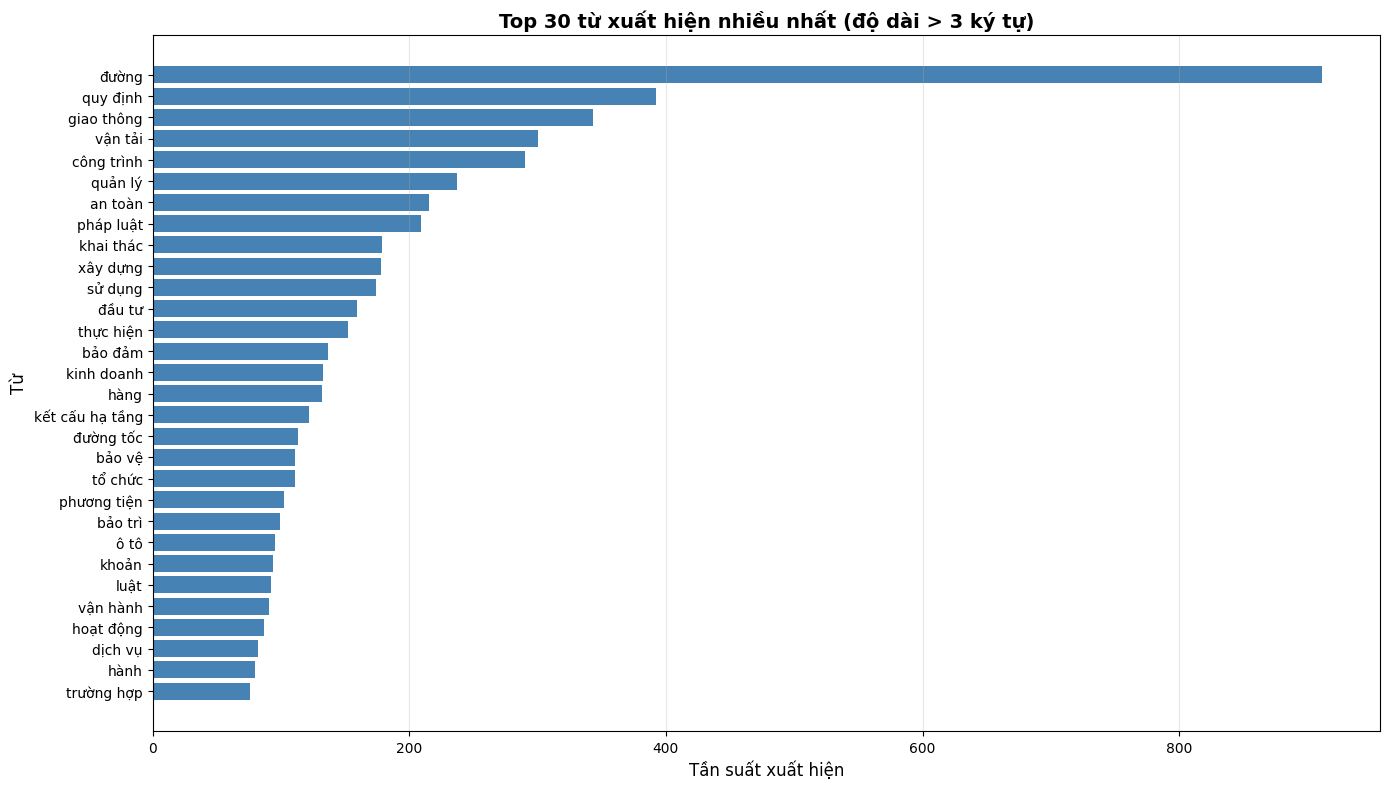

📊 Tổng số từ có độ dài > 3: 1,173


In [ ]:
import matplotlib.pyplot as plt

# Lọc từ có độ dài > 3
word_freq_filtered = {word: count for word, count in word_freq.items() if len(word) > 3}

# Lấy top 30 từ phổ biến nhất
top_words = sorted(word_freq_filtered.items(), key=lambda x: x[1], reverse=True)[:30]
words, counts = zip(*top_words)

# Vẽ biểu đồ
plt.figure(figsize=(14, 8))
plt.barh(range(len(words)), counts, color='steelblue')
plt.yticks(range(len(words)), words, fontsize=10)
plt.xlabel('Tần suất xuất hiện', fontsize=12)
plt.ylabel('Từ', fontsize=12)
plt.title('Top 30 từ xuất hiện nhiều nhất (độ dài > 3 ký tự)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Đảo ngược trục y để từ phổ biến nhất ở trên
plt.tight_layout()
plt.grid(axis='x', alpha=0.3)
plt.show()

print(f"Tổng số từ có độ dài > 3: {len(word_freq_filtered):,}")

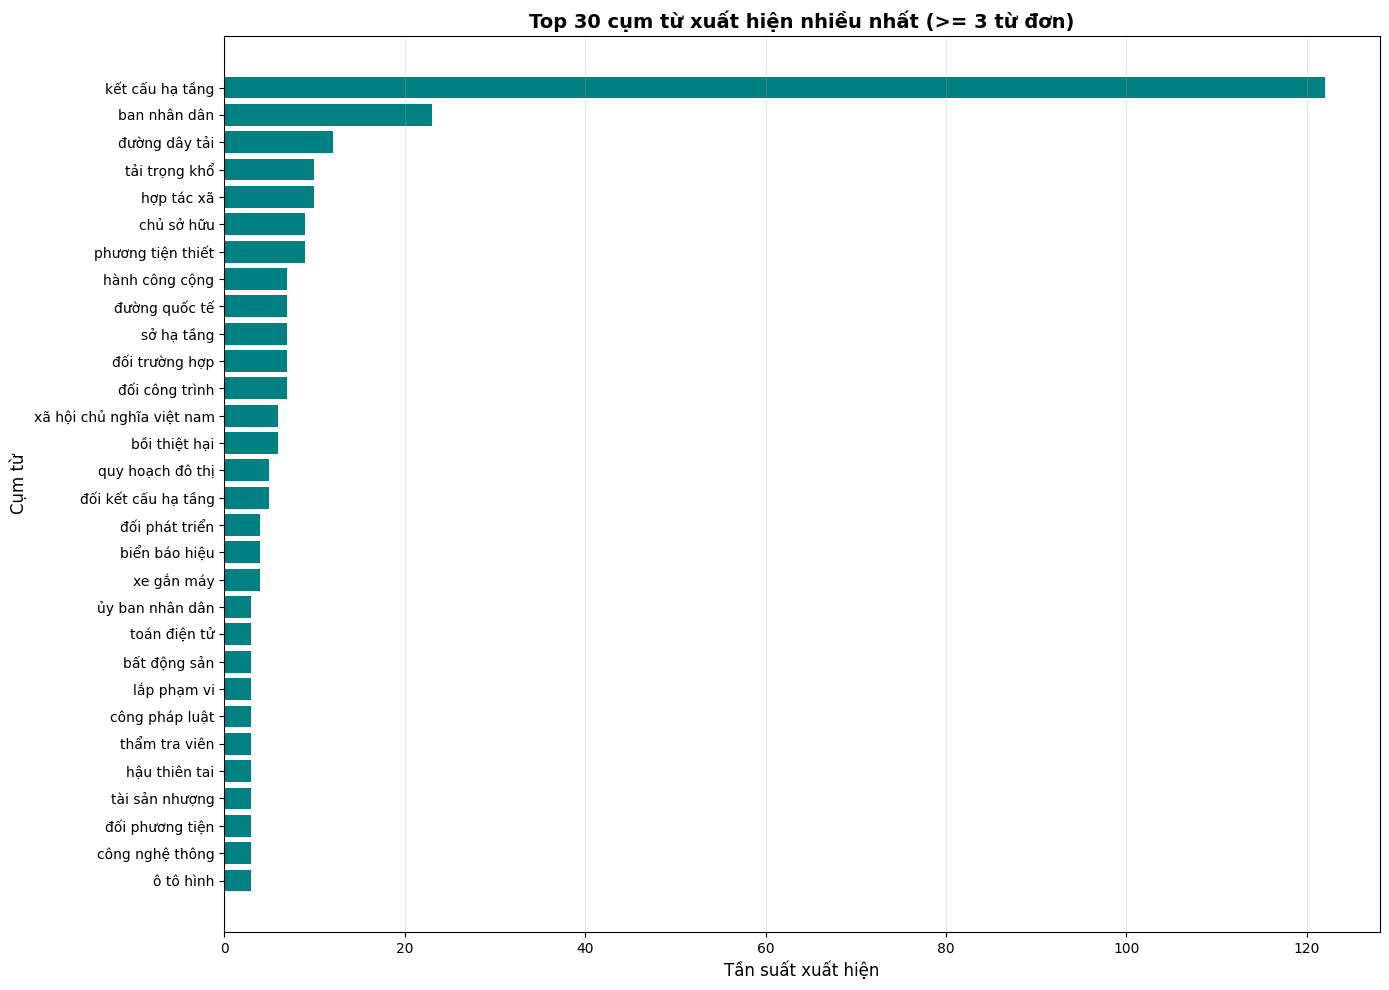

Tổng số cụm từ có >= 3 từ đơn: 185


In [ ]:
import matplotlib.pyplot as plt

# Lọc cụm từ có >= 3 từ đơn
# Trong list của underthesea, từ ghép có KHOẢNG TRẮNG, không phải dấu _
# Ví dụ: 'kết cấu hạ tầng' có 2 khoảng trắng → 3 từ đơn
word_freq_multi = {word: count for word, count in word_freq.items() 
                   if word.count(' ') >= 2}  # >= 3 từ đơn (đếm khoảng trắng)

# Lấy top 30 cụm từ phổ biến nhất
top_words = sorted(word_freq_multi.items(), key=lambda x: x[1], reverse=True)[:30]

if top_words:
    words, counts = zip(*top_words)
    
    # Vẽ biểu đồ
    plt.figure(figsize=(14, 10))
    plt.barh(range(len(words)), counts, color='teal')
    plt.yticks(range(len(words)), words, fontsize=10)
    plt.xlabel('Tần suất xuất hiện', fontsize=12)
    plt.ylabel('Cụm từ', fontsize=12)
    plt.title('Top 30 cụm từ xuất hiện nhiều nhất (>= 3 từ đơn)', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.grid(axis='x', alpha=0.3)
    plt.show()
    
    print(f"Tổng số cụm từ có >= 3 từ đơn: {len(word_freq_multi):,}")
else:
    print("Không tìm thấy cụm từ nào có >= 3 từ đơn")

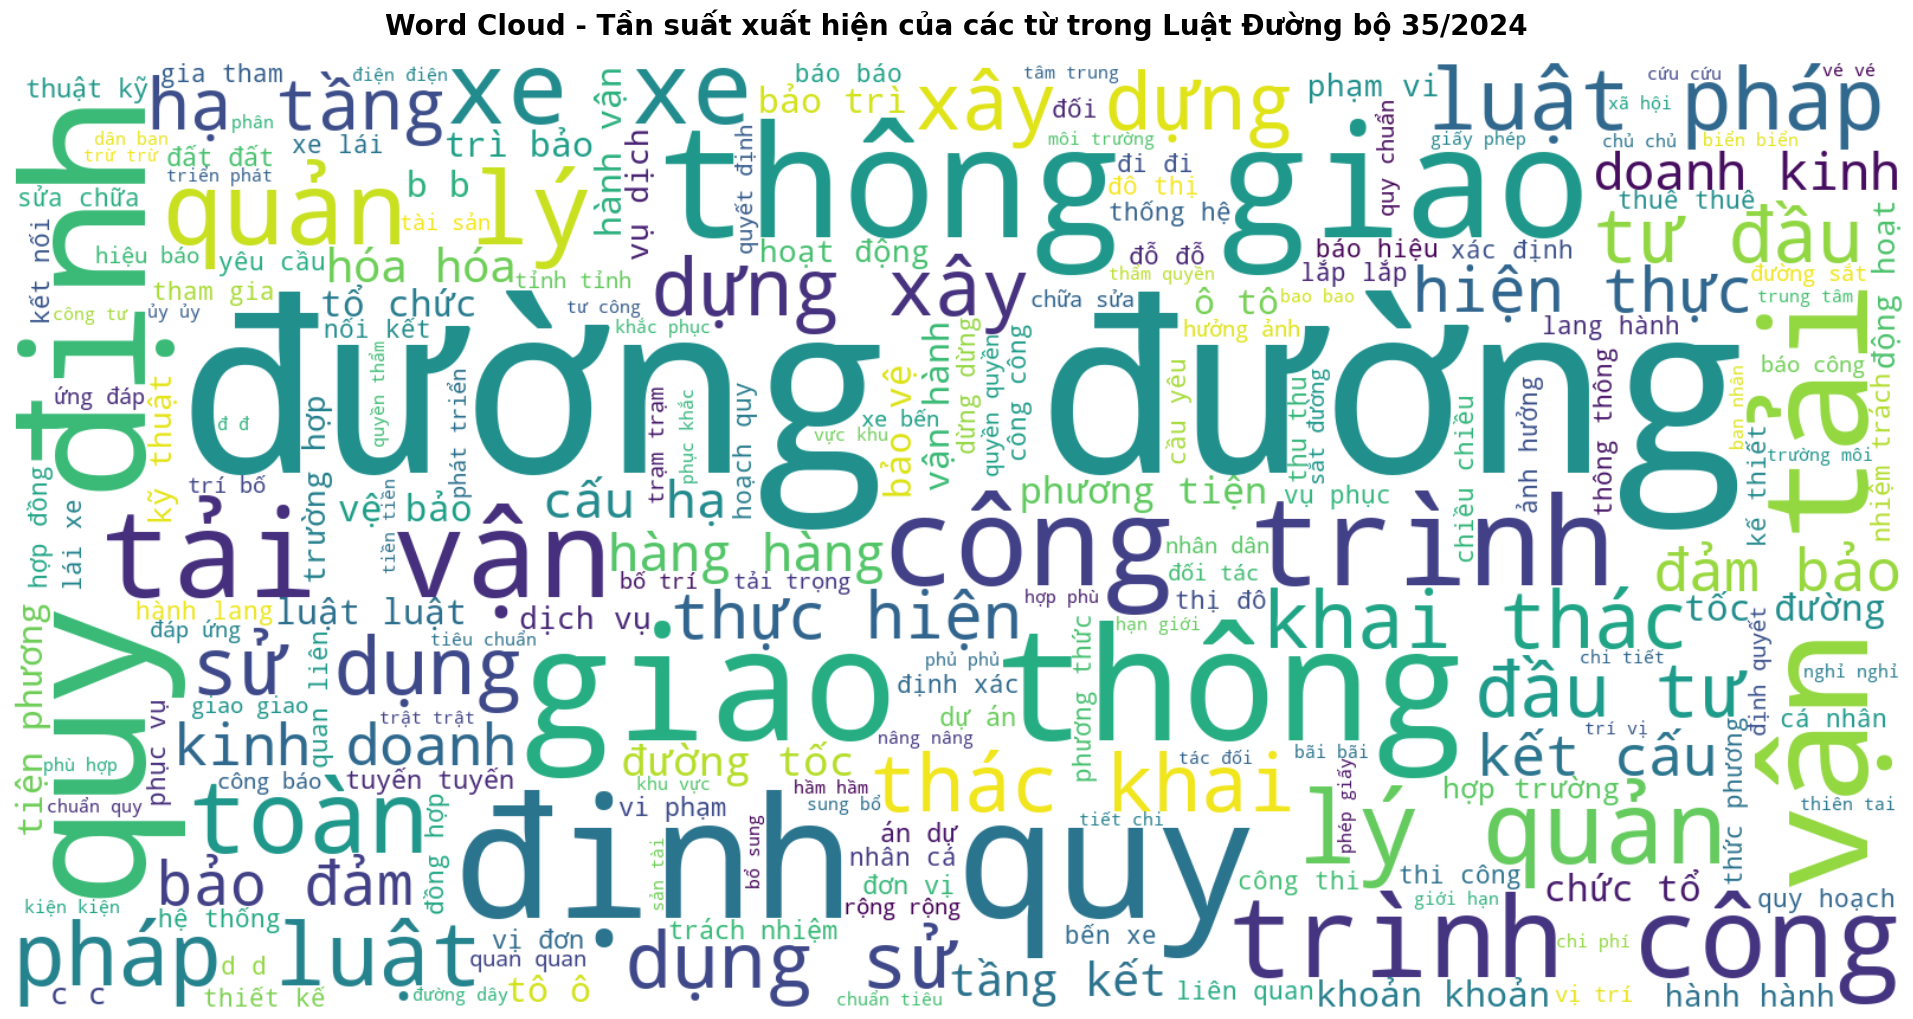

Đã tạo Word Cloud với 1460 từ duy nhất


In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Tạo text từ word_freq (từ xuất hiện nhiều lần sẽ lặp lại nhiều lần)
text_for_cloud = ' '.join([word for word, count in word_freq.items() for _ in range(count)])

# Tạo Word Cloud
wordcloud = WordCloud(
    width=1600, 
    height=800,
    background_color='white',
    colormap='viridis',  # Màu sắc đẹp
    max_words=200,       # Giới hạn 200 từ
    relative_scaling=0.5,
    min_font_size=10
).generate(text_for_cloud)

# Vẽ Word Cloud
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Tần suất xuất hiện của các từ trong Luật Đường bộ 35/2024', 
          fontsize=20, fontweight='bold', pad=20)
plt.tight_layout(pad=0)
plt.show()

print(f"Đã tạo Word Cloud với {len(word_freq)} từ duy nhất")